# 데이터 불러오기

In [73]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [74]:
df = pd.read_csv('./data/delivery_eta_train.csv')
df.head()

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level,Delivery_Time_min
0,11502,6.1,15,9,3,Clear,0.0,14.9,1.2,1,1,Dinner,Scooter,Suburban,0,2,59.7
1,12587,7.5,14,15,6,Clear,0.0,14.3,3.0,0,0,Lunch,Scooter,Downtown,1,3,62.9
2,12654,17.6,24,14,4,Rain,4.8,27.0,3.2,0,0,Dinner,Bike,Downtown,0,2,134.7
3,11056,6.8,15,11,5,Clear,0.0,9.2,5.4,0,3,Night,Scooter,Highway,0,0,60.1
4,10706,19.6,16,11,2,Clear,0.0,11.8,2.6,1,2,Dinner,Bike,Downtown,0,1,149.2


In [75]:
# 이건 뭐지?
df['Road_Type'].value_counts()

Road_Type
Downtown    1777
Suburban    1646
Highway      577
Name: count, dtype: int64

In [76]:
df.info()
# order_ID : 주문자 ID
# Distance_km : 배달 거리 - 표준화
# prep_Time_min : 음식 준비 시간 - 표준화
# Riders_Available : 배달원이 가게까지 도착하는데 걸리는 시간 - 표준화
# Order_Queue : 밀린 주문량
# Weather : 날씨가 어땠는지 - 표준화
# Rain_mm : 비가 왔다면 어느 정도 왔는지 - 표준화
# Temp_C : 날씨 온도는 어땠는지
# Rush_Hour : 러시 아워 유무
# DayOfWeek : 무슨 요일이었는지
# Time_slot : Morning, Lunch, Afternoon, Dinner, Night
# Vehicle : 무엇을 타고 배달 했는가
# Road_Type : 배달 경로 
# Promo : 할인 등의 프로모션이 진행 중이었는지
# Tip_Level : 배달 보너스? 
# Delivery_Time_min : 배달에 얼마나 걸렸는지 <- Target, Label 값

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           4000 non-null   int64  
 1   Distance_km        4000 non-null   float64
 2   Prep_Time_min      4000 non-null   int64  
 3   Riders_Available   4000 non-null   int64  
 4   Order_Queue        4000 non-null   int64  
 5   Weather            4000 non-null   str    
 6   Rain_mm            4000 non-null   float64
 7   Temp_C             4000 non-null   float64
 8   Wind_mps           4000 non-null   float64
 9   Rush_Hour          4000 non-null   int64  
 10  DayOfWeek          4000 non-null   int64  
 11  Time_Slot          4000 non-null   str    
 12  Vehicle            4000 non-null   str    
 13  Road_Type          4000 non-null   str    
 14  Promo              4000 non-null   int64  
 15  Tip_Level          4000 non-null   int64  
 16  Delivery_Time_min  4000 non-null   

In [77]:
# 이상치가 없는 것 같은데?
df.describe()

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Promo,Tip_Level,Delivery_Time_min
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000
mean,12488.605000,5.974750,14.997500,8.006250,4.048500,1.323450,13.051725,2.809450,0.401250,2.940000,0.294500,1.50425,66.745900
std,1450.904584,4.076066,5.017847,4.344183,2.044919,2.706038,9.193198,1.200715,0.490213,2.013557,0.455875,1.11973,22.278719
min,10001.000000,0.300000,3.000000,1.000000,0.000000,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,0.00000,20.100000
25%,11234.750000,2.900000,12.000000,4.000000,3.000000,0.000000,7.100000,2.000000,0.000000,1.000000,0.000000,0.00000,50.700000
50%,12469.500000,5.100000,15.000000,8.000000,4.000000,0.000000,13.150000,2.800000,0.000000,3.000000,0.000000,2.00000,63.100000
75%,13758.250000,8.100000,18.000000,12.000000,5.000000,1.600000,19.100000,3.600000,1.000000,5.000000,1.000000,3.00000,79.125000
max,15000.000000,20.000000,36.000000,15.000000,13.000000,24.900000,35.000000,7.800000,1.000000,6.000000,1.000000,3.00000,150.000000


<Axes: xlabel='Distance_km', ylabel='Count'>

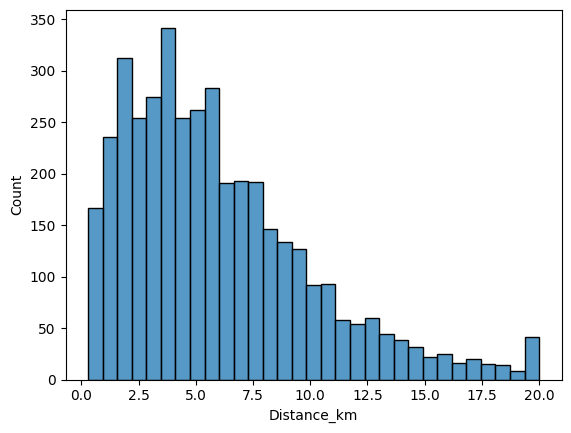

In [78]:
# 그래도 확인해보자.
sns.histplot(df['Distance_km'])

In [79]:
# 필요없는 열 제거하고 피쳐 컬럼과 레이블 컬럼을 나눔.
X_train = df.drop(['Delivery_Time_min','Order_ID'], axis=1)
y_train = df['Delivery_Time_min']

In [80]:
# 확인
X_train

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level
0,6.1,15,9,3,Clear,0.0,14.9,1.2,1,1,Dinner,Scooter,Suburban,0,2
1,7.5,14,15,6,Clear,0.0,14.3,3.0,0,0,Lunch,Scooter,Downtown,1,3
2,17.6,24,14,4,Rain,4.8,27.0,3.2,0,0,Dinner,Bike,Downtown,0,2
3,6.8,15,11,5,Clear,0.0,9.2,5.4,0,3,Night,Scooter,Highway,0,0
4,19.6,16,11,2,Clear,0.0,11.8,2.6,1,2,Dinner,Bike,Downtown,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,2.5,14,1,5,Clear,0.0,16.1,1.7,0,5,Lunch,Scooter,Suburban,0,3
3996,3.3,13,1,5,Rain,0.3,20.6,5.5,1,5,Morning,Scooter,Downtown,0,0
3997,3.6,13,8,4,Clear,0.0,11.0,1.1,0,0,Morning,Scooter,Suburban,0,0
3998,1.6,15,15,8,Clear,0.0,17.8,0.0,0,4,Dinner,Bike,Suburban,0,2


In [81]:
# 확인2
y_train

0        59.7
1        62.9
2       134.7
3        60.1
4       149.2
        ...  
3995     50.5
3996     70.5
3997     43.8
3998     41.3
3999     27.7
Name: Delivery_Time_min, Length: 4000, dtype: float64

# 표준화

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [83]:
# 표준화 할 수치 데이터 컬럼만 모아서 담아두기
num_X_train = X_train.select_dtypes(include='number')
num_X_train

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Promo,Tip_Level
0,6.1,15,9,3,0.0,14.9,1.2,1,1,0,2
1,7.5,14,15,6,0.0,14.3,3.0,0,0,1,3
2,17.6,24,14,4,4.8,27.0,3.2,0,0,0,2
3,6.8,15,11,5,0.0,9.2,5.4,0,3,0,0
4,19.6,16,11,2,0.0,11.8,2.6,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...
3995,2.5,14,1,5,0.0,16.1,1.7,0,5,0,3
3996,3.3,13,1,5,0.3,20.6,5.5,1,5,0,0
3997,3.6,13,8,4,0.0,11.0,1.1,0,0,0,0
3998,1.6,15,15,8,0.0,17.8,0.0,0,4,0,2


In [84]:
# 한꺼번에 표준화 하기
scaled_num_X_train = scaler.fit_transform(num_X_train)
scaled_num_X_train

array([[ 3.07319979e-02,  4.98283938e-04,  2.28782757e-01, ...,
        -9.63589366e-01, -6.46091668e-01,  4.42795994e-01],
       [ 3.74243352e-01, -1.98815291e-01,  1.61011261e+00, ...,
        -1.46028491e+00,  1.54776799e+00,  1.33598005e+00],
       [ 2.85243240e+00,  1.79432046e+00,  1.37989097e+00, ...,
        -1.46028491e+00, -6.46091668e-01,  4.42795994e-01],
       ...,
       [-5.82681134e-01, -3.98128866e-01, -1.43888526e-03, ...,
        -1.46028491e+00, -6.46091668e-01, -1.34357211e+00],
       [-1.07341164e+00,  4.98283938e-04,  1.61011261e+00, ...,
         5.26497282e-01, -6.46091668e-01,  4.42795994e-01],
       [-1.04887511e+00, -1.98815291e-01,  1.37989097e+00, ...,
         5.26497282e-01, -6.46091668e-01,  4.42795994e-01]],
      shape=(4000, 11))

In [85]:
# 표준화한 데이터들 다시 X_train 데이터 프레임에다가 넣기
X_train[['Distance_km','Prep_Time_min','Riders_Available','Order_Queue','Rain_mm','Temp_C','Wind_mps','Rush_Hour','DayOfWeek','Promo','Tip_Level']] = scaled_num_X_train
X_train.head()

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level
0,0.030732,0.000498,0.228783,-0.512798,Clear,-0.489134,0.201073,-1.340577,1.221561,-0.963589,Dinner,Scooter,Suburban,-0.646092,0.442796
1,0.374243,-0.198815,1.610113,0.954436,Clear,-0.489134,0.135799,0.158717,-0.818625,-1.460285,Lunch,Scooter,Downtown,1.547768,1.335980
2,2.852432,1.794320,1.379891,-0.023720,Rain,1.284899,1.517428,0.325305,-0.818625,-1.460285,Dinner,Bike,Downtown,-0.646092,0.442796
3,0.202488,0.000498,0.689226,0.465358,Clear,-0.489134,-0.419028,2.157776,-0.818625,0.029802,Night,Scooter,Highway,-0.646092,-1.343572
4,3.343163,0.199812,0.689226,-1.001876,Clear,-0.489134,-0.136175,-0.174460,1.221561,-0.466894,Dinner,Bike,Downtown,-0.646092,-0.450388


# 범주형 인코딩

In [86]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [87]:
# 문자열 컬럼만 보기
str_cols = X_train.select_dtypes(include=["object", "string"]).columns
X_train[str_cols].head()

,Weather,Time_Slot,Vehicle,Road_Type
0,Clear,Dinner,Scooter,Suburban
1,Clear,Lunch,Scooter,Downtown
2,Rain,Dinner,Bike,Downtown
3,Clear,Night,Scooter,Highway
4,Clear,Dinner,Bike,Downtown


In [88]:
# 문자열 컬럼들 원핫인코딩
# 원핫인코딩을 하면 컬럼의 values 값 유무에 따라 0,1로 인코딩된다.
# 2차원 배열
X_ohe = ohe.fit_transform(X_train[str_cols])
X_ohe

array([[1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.]], shape=(4000, 15))

In [89]:
df['Weather'].value_counts()

Weather
Clear    2522
Rain      975
Snow      259
Fog       244
Name: count, dtype: int64

In [90]:
# 인코딩 결과물을 다시 데이터프레임화 하기 위해 각 요소의 이름을 가져온다.
# 예를 들어 Weather의 경우, Clear, Rain, Snow, Fog 4개의 values를 갖고 있다.
# 따라서 인코딩 된 Weather의 각 요소는 Weather_Clear, Weather_Rain, Weather_Snow, Weather_Fog의 이름을 갖는다.
# get_feature_names_out <feature의 이름을 가져오는 함수
ohe_cols = ohe.get_feature_names_out(str_cols)
ohe_cols

array(['Weather_Clear', 'Weather_Fog', 'Weather_Rain', 'Weather_Snow',
       'Time_Slot_Afternoon', 'Time_Slot_Dinner', 'Time_Slot_Lunch',
       'Time_Slot_Morning', 'Time_Slot_Night', 'Vehicle_Bike',
       'Vehicle_Car', 'Vehicle_Scooter', 'Road_Type_Downtown',
       'Road_Type_Highway', 'Road_Type_Suburban'], dtype=object)

In [91]:
# 데이터 프레임화 = 값은 인코딩한 결과물, 컬럼은 각 feature의 이름, 인덱스는 본래 인덱스)
df_ohe = pd.DataFrame(X_ohe, columns=ohe_cols, index=X_train.index)
df_ohe

,Weather_Clear,Weather_Fog,Weather_Rain,Weather_Snow,Time_Slot_Afternoon,Time_Slot_Dinner,Time_Slot_Lunch,Time_Slot_Morning,Time_Slot_Night,Vehicle_Bike,Vehicle_Car,Vehicle_Scooter,Road_Type_Downtown,Road_Type_Highway,Road_Type_Suburban
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3997,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3998,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [92]:
# pd.concat 여러개의 pandas 객체를 붙이는 함수, 세로는 axis=0, 가로는 axis=1
# 위에 만든 데이터프레임을 가로로 붙이고 본래 컬럼들은 드롭한다.
X_train_scaled = pd.concat([X_train.drop(columns=str_cols), df_ohe], axis=1)
X_train_scaled.head()

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Promo,...,Time_Slot_Dinner,Time_Slot_Lunch,Time_Slot_Morning,Time_Slot_Night,Vehicle_Bike,Vehicle_Car,Vehicle_Scooter,Road_Type_Downtown,Road_Type_Highway,Road_Type_Suburban
0,0.030732,0.000498,0.228783,-0.512798,-0.489134,0.201073,-1.340577,1.221561,-0.963589,-0.646092,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.374243,-0.198815,1.610113,0.954436,-0.489134,0.135799,0.158717,-0.818625,-1.460285,1.547768,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,2.852432,1.794320,1.379891,-0.023720,1.284899,1.517428,0.325305,-0.818625,-1.460285,-0.646092,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.202488,0.000498,0.689226,0.465358,-0.489134,-0.419028,2.157776,-0.818625,0.029802,-0.646092,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,3.343163,0.199812,0.689226,-1.001876,-0.489134,-0.136175,-0.174460,1.221561,-0.466894,-0.646092,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Test Data

## 테스트데이터 불러오기

In [93]:
df_test = pd.read_csv('./data/delivery_eta_test.csv')
df_test

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level,Delivery_Time_min
0,11702,16.4,14,7,2,Rain,2.8,34.3,2.2,0,2,Dinner,Car,Downtown,1,1,100.5
1,13294,5.3,16,14,4,Clear,0.0,7.0,2.6,1,2,Lunch,Bike,Downtown,0,3,66.3
2,12162,5.4,13,8,6,Rain,1.7,22.6,3.6,1,4,Dinner,Bike,Downtown,0,1,76.3
3,11137,20.0,17,3,1,Rain,4.8,28.0,3.0,1,2,Lunch,Scooter,Suburban,0,1,146.4
4,10988,7.4,16,11,0,Snow,8.1,21.4,2.8,0,0,Dinner,Scooter,Downtown,0,2,79.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,14427,5.8,20,1,8,Clear,0.0,13.6,3.2,1,1,Afternoon,Scooter,Downtown,0,1,78.7
996,10467,4.2,22,7,3,Clear,0.0,16.2,3.2,1,6,Afternoon,Scooter,Downtown,0,0,65.6
997,13093,12.7,18,13,2,Clear,0.0,5.6,2.4,0,1,Afternoon,Bike,Highway,1,2,85.4
998,13773,0.8,16,7,2,Clear,0.0,4.5,6.0,1,3,Afternoon,Bike,Downtown,0,2,37.3


## 데이터 나누기

In [94]:
X_test = df_test.drop(['Order_ID','Delivery_Time_min'], axis=1)
y_test = df_test['Delivery_Time_min']

In [95]:
print(X_test.shape)
print(y_test.shape)

(1000, 15)
(1000,)


## 표준화

In [96]:
# train 데이터와 형태를 똑같이 만들어주는 작업을 진행한다.
num_X_test = X_test.select_dtypes(include='number')
num_X_test

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Promo,Tip_Level
0,16.4,14,7,2,2.8,34.3,2.2,0,2,1,1
1,5.3,16,14,4,0.0,7.0,2.6,1,2,0,3
2,5.4,13,8,6,1.7,22.6,3.6,1,4,0,1
3,20.0,17,3,1,4.8,28.0,3.0,1,2,0,1
4,7.4,16,11,0,8.1,21.4,2.8,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...
995,5.8,20,1,8,0.0,13.6,3.2,1,1,0,1
996,4.2,22,7,3,0.0,16.2,3.2,1,6,0,0
997,12.7,18,13,2,0.0,5.6,2.4,0,1,1,2
998,0.8,16,7,2,0.0,4.5,6.0,1,3,0,2


In [97]:
scaled_num_X_test = scaler.fit_transform(num_X_test)
scaled_num_X_test

array([[ 2.58765445, -0.1889815 , -0.24606116, ..., -0.5280114 ,
         1.5685049 , -0.43205828],
       [-0.16907969,  0.22773625,  1.35470848, ..., -0.5280114 ,
        -0.63754981,  1.35700293],
       [-0.14424425, -0.39734038, -0.01737978, ...,  0.46542492,
        -0.63754981, -0.43205828],
       ...,
       [ 1.66874307,  0.64445401,  1.1260271 , ..., -1.02472956,
         1.5685049 ,  0.46247232],
       [-1.28667462,  0.22773625, -0.24606116, ..., -0.03129324,
        -0.63754981,  0.46247232],
       [-0.21875058,  0.22773625,  0.89734572, ..., -0.03129324,
        -0.63754981,  1.35700293]], shape=(1000, 11))

In [98]:
X_test[[
    'Distance_km','Prep_Time_min','Riders_Available','Order_Queue','Rain_mm','Temp_C',
    'Wind_mps','Rush_Hour','DayOfWeek','Promo','Tip_Level'
    ]] = scaled_num_X_test
X_test.head()

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level
0,2.587654,-0.188982,-0.246061,-0.984650,Rain,0.471919,2.255961,-0.474099,-0.823318,-0.528011,Dinner,Car,Downtown,1.568505,-0.432058
1,-0.169080,0.227736,1.354708,0.052916,Clear,-0.492798,-0.696061,-0.139224,1.214598,-0.528011,Lunch,Bike,Downtown,-0.637550,1.357003
2,-0.144244,-0.397340,-0.017380,1.090482,Rain,0.092923,0.990809,0.697963,1.214598,0.465425,Dinner,Bike,Downtown,-0.637550,-0.432058
3,3.481730,0.436095,-1.160787,-1.503433,Rain,1.161003,1.574725,0.195651,1.214598,-0.528011,Lunch,Scooter,Suburban,-0.637550,-0.432058
4,0.352465,0.227736,0.668664,-2.022216,Snow,2.297991,0.861050,0.028213,-0.823318,-1.521448,Dinner,Scooter,Downtown,-0.637550,0.462472


## 범주형

In [99]:
test_str_cols = X_test.select_dtypes(include=["object", "string"]).columns
X_test[test_str_cols].head()

,Weather,Time_Slot,Vehicle,Road_Type
0,Rain,Dinner,Car,Downtown
1,Clear,Lunch,Bike,Downtown
2,Rain,Dinner,Bike,Downtown
3,Rain,Lunch,Scooter,Suburban
4,Snow,Dinner,Scooter,Downtown


In [100]:
X_test_ohe = ohe.fit_transform(X_test[test_str_cols])
X_test_ohe

array([[0., 0., 1., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(1000, 15))

In [101]:
test_ohe_cols = ohe.get_feature_names_out(test_str_cols)
test_ohe_cols

array(['Weather_Clear', 'Weather_Fog', 'Weather_Rain', 'Weather_Snow',
       'Time_Slot_Afternoon', 'Time_Slot_Dinner', 'Time_Slot_Lunch',
       'Time_Slot_Morning', 'Time_Slot_Night', 'Vehicle_Bike',
       'Vehicle_Car', 'Vehicle_Scooter', 'Road_Type_Downtown',
       'Road_Type_Highway', 'Road_Type_Suburban'], dtype=object)

In [102]:
df_test_ohe = pd.DataFrame(X_test_ohe, columns=test_ohe_cols, index=X_test.index)
df_test_ohe

,Weather_Clear,Weather_Fog,Weather_Rain,Weather_Snow,Time_Slot_Afternoon,Time_Slot_Dinner,Time_Slot_Lunch,Time_Slot_Morning,Time_Slot_Night,Vehicle_Bike,Vehicle_Car,Vehicle_Scooter,Road_Type_Downtown,Road_Type_Highway,Road_Type_Suburban
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
996,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
998,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [103]:
X_test_scaled = pd.concat([X_test.drop(columns=test_str_cols), df_test_ohe], axis=1)
X_test_scaled.head()

,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Promo,...,Time_Slot_Dinner,Time_Slot_Lunch,Time_Slot_Morning,Time_Slot_Night,Vehicle_Bike,Vehicle_Car,Vehicle_Scooter,Road_Type_Downtown,Road_Type_Highway,Road_Type_Suburban
0,2.587654,-0.188982,-0.246061,-0.984650,0.471919,2.255961,-0.474099,-0.823318,-0.528011,1.568505,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.169080,0.227736,1.354708,0.052916,-0.492798,-0.696061,-0.139224,1.214598,-0.528011,-0.637550,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.144244,-0.397340,-0.017380,1.090482,0.092923,0.990809,0.697963,1.214598,0.465425,-0.637550,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,3.481730,0.436095,-1.160787,-1.503433,1.161003,1.574725,0.195651,1.214598,-0.528011,-0.637550,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.352465,0.227736,0.668664,-2.022216,2.297991,0.861050,0.028213,-0.823318,-1.521448,-0.637550,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


# 모델 학습

In [104]:
# 모양이 맞는지 확인
print(X_train_scaled.shape)
print(y_train.shape)
print(X_test_scaled.shape)
print(y_test.shape)

(4000, 26)
(4000,)
(1000, 26)
(1000,)


In [105]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [106]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [107]:
pred = model.predict(X_test_scaled)
pred

array([116.28934084,  65.44722465,  76.90572199, 140.84137463,
        82.6479998 ,  66.39544218,  35.38251995,  66.12780929,
        55.19245845,  47.53355461,  59.18100249,  52.69449811,
        45.44878053,  68.24048912,  52.19960071,  58.32210259,
        83.51505274, 104.64058161,  38.0830121 ,  67.16816645,
        49.30848359, 121.00697747,  85.99765778,  81.2613431 ,
        89.66329589,  68.15973875,  38.02841008,  42.18785778,
        93.28736292,  70.98719323,  67.99474819, 114.99319452,
       127.63568   ,  70.98742218,  59.02661733,  56.75469739,
        28.42348873,  50.92419038,  63.65140007,  92.62857002,
       101.22629935,  53.23910607,  71.09846773,  97.52303094,
        54.52087631, 125.31671039, 134.62573012,  49.78091112,
        77.66039483,  78.46679837,  73.46712584, 103.32403756,
        51.75547812,  40.67575058, 100.47453101,  58.75948584,
        52.99857098,  54.87554544, 122.36943217,  56.62322051,
        41.1861776 ,  51.30127126,  61.68741313,  83.23

In [108]:
mae = mean_absolute_error(y_test,pred)
mae

3.8217616003464348

In [124]:
#평가
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,pred)

print('MAE : ',mae)
print('MSE : ',mse)
print('RMSE : ',rmse)
print('r2 : ',r2)

MAE :  3.8217616003464348
MSE :  23.415853275975024
RMSE :  4.838993002265557
r2 :  0.9501485599509775


## Ridge, Lasso

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

r_model = Ridge()
l_model = Lasso()

r_param = {'alpha' : [0.1,]}



## 다항회귀

In [110]:
# 2. 다항 특성 생성 (2차)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# 3. 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 4. 예측 실행
y_pred = model.predict(X_test_poly)

# 5. 성능 평가
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"다항회귀 설명력(R2 Score): {r2:.4f}")
print(f"평균 오차(MAE): {mae:.2f}분")

다항회귀 설명력(R2 Score): 0.9625
평균 오차(MAE): 3.33분


## DecisionTree

In [130]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [121]:
dt = DecisionTreeRegressor(
    random_state=3333,
    max_depth=4
)

dt.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",3333
,"max_le

In [122]:
dt_pred = dt.predict(X_test_scaled)
dt_pred

array([120.2238806 ,  54.99409283,  65.59325   , 139.81463415,
        93.67666667,  54.99409283,  47.80465587,  64.26153846,
        74.75888112,  51.97385445,  63.63127036,  51.97385445,
        51.97385445,  65.59325   ,  51.97385445,  54.99409283,
        74.75888112,  97.17006803,  47.80465587,  85.96190476,
        47.80465587, 101.19035088,  74.75888112,  74.75888112,
       114.52222222,  51.97385445,  51.97385445,  47.80465587,
        85.96190476,  74.75888112,  74.75888112, 114.52222222,
       139.81463415,  74.75888112,  54.99409283,  54.99409283,
        39.65014327,  54.99409283,  51.97385445,  93.67666667,
        85.96190476,  54.99409283,  63.63127036,  97.17006803,
        54.99409283, 120.2238806 , 139.81463415,  54.99409283,
        74.75888112,  63.63127036,  74.75888112,  97.17006803,
        51.97385445,  39.65014327, 101.19035088,  65.59325   ,
        51.97385445,  63.63127036, 114.52222222,  54.99409283,
        51.97385445,  54.99409283,  54.99409283,  65.59

In [126]:
mae = mean_absolute_error(y_test,dt_pred)
mse = mean_squared_error(y_test,dt_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,dt_pred)

print('MAE : ',mae)
print('MSE : ',mse)
print('RMSE : ',rmse)
print('r2 : ',r2)

MAE :  7.380078000418376
MSE :  85.7584101790121
RMSE :  9.260583684574753
r2 :  0.8174236832904613


## Random Forest

In [136]:
rf = RandomForestRegressor(
    n_estimators=300,      # 나무 개수
    random_state=3333,
    max_depth=None,        # 필요 시 제한 가능
    n_jobs=-1
)

In [137]:
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [138]:
rf_pred = rf.predict(X_test_scaled)
rf_pred

array([112.55633333,  66.8       ,  71.36466667, 139.399     ,
        90.66433333,  65.73833333,  36.743     ,  64.58633333,
        65.62833333,  46.94533333,  62.06233333,  56.597     ,
        47.69933333,  64.87333333,  53.66033333,  60.00733333,
        74.78666667, 104.896     ,  41.12266667,  71.40366667,
        51.94433333, 114.537     ,  79.72666667,  78.635     ,
       101.122     ,  60.11333333,  47.823     ,  45.533     ,
        88.75633333,  71.432     ,  73.81833333, 112.58566667,
       139.945     ,  73.29966667,  64.27133333,  55.18866667,
        32.58166667,  53.80733333,  62.97      ,  93.891     ,
        96.85333333,  53.392     ,  72.05533333,  92.44      ,
        55.022     , 121.58366667, 130.774     ,  47.67633333,
        76.78433333,  73.372     ,  84.56266667, 105.81566667,
        49.38333333,  43.90766667,  99.223     ,  61.04166667,
        52.21366667,  54.875     , 126.275     ,  57.308     ,
        45.28666667,  50.567     ,  61.49866667,  73.98

In [139]:
mae = mean_absolute_error(y_test,rf_pred)
mse = mean_squared_error(y_test,rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,rf_pred)

print('MAE : ',mae)
print('MSE : ',mse)
print('RMSE : ',rmse)
print('r2 : ',r2)

MAE :  4.352336999999998
MSE :  29.53962148588886
RMSE :  5.43503647512037
r2 :  0.9371112958294154
